In [ ]:
import numpy as np
import copy
from packboost.core import PackBoost
import time

X = np.random.randint(0, 5, (10000, 500), dtype='i1')
y = np.random.randn(10000).astype('f4')

model = PackBoost()
start = time.time()
model.fit(
    X, y,
    rounds=500,
    max_depth=8,
    nfolds=1,
    lr=0.05
)
end = time.time()
print(f"Training completed in {end - start:.2f} seconds")

In [8]:
X_test = np.random.randint(0, 5, (2000, 500), dtype='i1')
model_gpu = copy.deepcopy(model)
model_gpu.device = 'cuda'
preds_gpu = model_gpu.predict(X_test)
preds_gpu

array([ -109149,   257660, -3281630, ...,  -874391, -3010182, -2881931],
      shape=(2000,), dtype=int32)

In [9]:
model_cpu = copy.deepcopy(model)
# Ensure tensors are on CPU
model_cpu.device = 'cpu'
preds_cpu = model_cpu.predict(X_test)
preds_cpu

array([ -109149,   257660, -3281630, ...,  -874391, -3010182, -2881931],
      shape=(2000,), dtype=int32)

## compare cpu vs gpu P

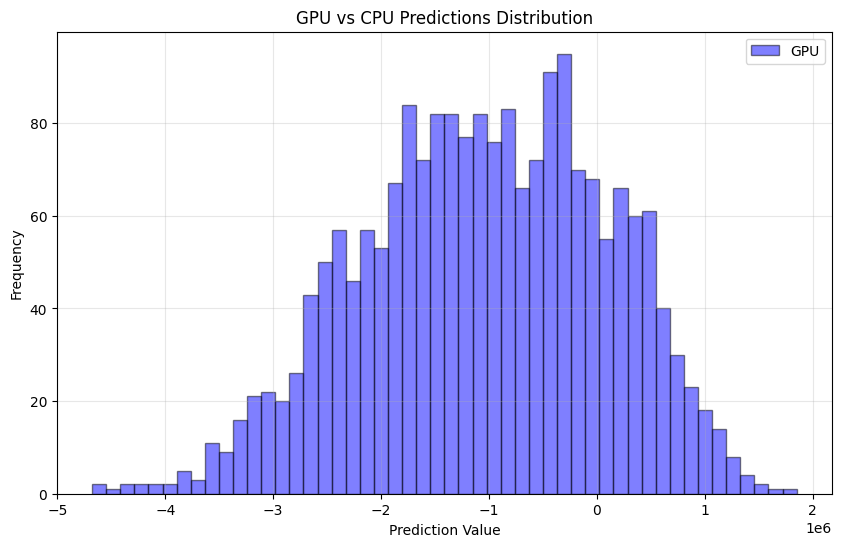

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(preds_gpu, bins=50, alpha=0.5, label='GPU', color='blue', edgecolor='black')
plt.xlabel('Prediction Value')
plt.ylabel('Frequency')
plt.title('GPU vs CPU Predictions Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

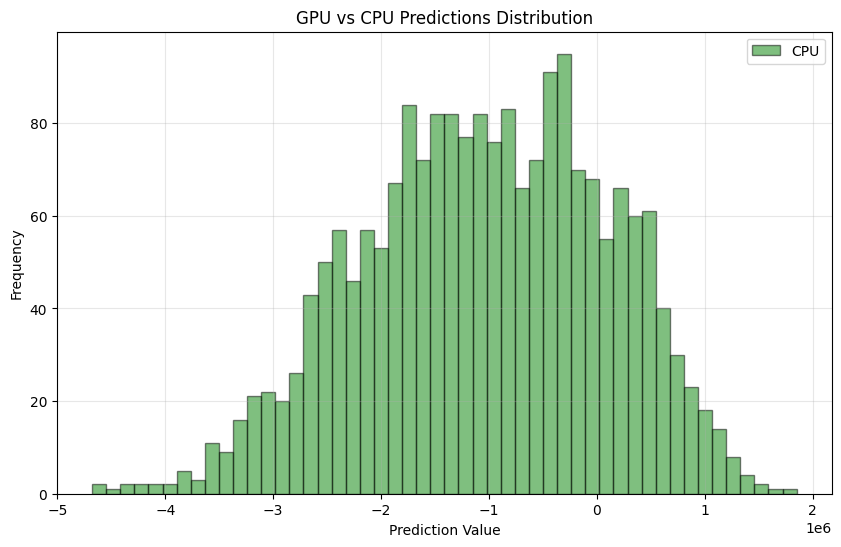

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(preds_cpu, bins=50, alpha=0.5, label='CPU', color='green', edgecolor='black')
plt.xlabel('Prediction Value')
plt.ylabel('Frequency')
plt.title('GPU vs CPU Predictions Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()